In [175]:
# Initialize Otter
import otter
grader = otter.Notebook("hw4.ipynb")

# Hw 4: Sentiment Analysis on Scraped News Data 🗞️

### Collaborators and Sources
In addition to recording your **collaborators** (TAs, peers, group members, roommates, etc.) on this homework in the cell below, you are required to **cite/indicate all external sources** used when finishing this assignment. 
External sources are defined as anything that is not considered course material, such as online sources (webpages, blog posts, etc.), content generated by AI systems, books, etc.

When using external sources, indicate what kind of external sources (e.g. stack overflow, WashU chatGPT, etc.) you used in the cell below and then provide more specific citations (such as links to webpages or in case of AI generated asnwers the actual sources (links provided by the AI system) and the prompt used to generate the answers) with your answer to **each specific problem**.  


Note that these citations will not free you from your obligation to submit your _own_ code and write-ups, however, they will be taken into account during the grading and regrading process, **especially** when two or more submissions closely resemble each other. Working with each other is ok, as long as you cite who you worked with and you don't copy anyone's answers directly!

### Submission instructions
* Submit this Python notebook on Gradescope.
* Execute all cells and save your notebook prior to submission. 
* Don't forget to commit and push to your Github repo!
* **Do not change the number of cells!** Your submission notebook should have exactly one code cell per problem. 
* Do **not** remove the `# your code here` line. Add your solution **after** that line. 

## Let's get started

For this homework, work through **Lab 4 (Sentiment Analysis on Movie Reviews)** first. Most of the things we ask you to do in this homework are explained in the lab. In general, you should feel free to import any package that we have previously used in class. Ensure that all plots have the necessary components that a plot should have (e.g. axes labels, a title, and a legend if it is applicable).

Frequently **save** your notebook!

### Some imports and configurations

In [176]:
!pip install beautifulsoup4 requests

In [177]:
import sys
import requests
from bs4 import BeautifulSoup
import re, string
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import datetime
import time

In [178]:
# %%javascript
# IPython.OutputArea.prototype._should_scroll = function(lines) {
#     return false;
# }

## 0. Web Scraping Intro

In this homework, we'll aquire data by scraping it from web pages. Fetching web pages, it turns out, is pretty easy; getting meaningful structured information out of them less so.

### HTML and the Parsing Thereof

Pages on the Web are written in HTML, in which text is (ideally) marked up into elements and their attributes:
```
<html>
  <head>
    <title>A web page</title>
  </head>
  <body>
    <p id="author">John Smith</p>
    <p id="subject">Data Science</p>
  </body>
</html>
```
In a perfect world, where all web pages are marked up semantically for our benefit, we would be able to extract data using rules like “find the `<p>` element whose id is author and return the text it contains.” In the actual world, HTML is not generally well-formed, let alone annotated. This means we’ll need help making sense of it.

To get data out of HTML, we will use the [BeautifulSoup library](http://www.crummy.com/software/BeautifulSoup/), which builds a tree out of the various elements on a web page and provides a simple interface for accessing them. We’ll also be using the [requests library](http://docs.python-requests.org/en/latest/), which is a much nicer way of making HTTP requests than anything that’s built into Python.

To use Beautiful Soup, we’ll need to pass some HTML into the BeautifulSoup() function. In our examples, this will be the result of a call to requests.get:
```
html = requests.get("http://www.example.com")
soup = BeautifulSoup(html.content, "html.parser")
```
after which we can get pretty far using a few simple methods.

We’ll typically work with Tag objects, which correspond to the tags representing the structure of an HTML page. For example, to find the first `<p>` tag (and extract its contents) you can use:
```
first_paragraph = soup.find('p').text
```
You can get multiple tags at once:
```
paragraphs = [p.text for p in soup.find_all('p')]
```
Frequently you’ll want to find tags with a specific class:
```
paragraphs = [p.text for p in soup.find_all('p', class_="example_class")]
```
will extract the text from each `<p>` tag with the class `example_class`. 

Just these handful of features will allow us to do quite a lot. If you end up needing to do more-complicated things (or if you’re just curious), check the [documentation](https://www.crummy.com/software/BeautifulSoup/bs4/doc/#). [Adapted from Joel Grus's [Data Science from Scratch](https://learning.oreilly.com/library/view/data-science-from/9781492041122/)]

## 1. Get and Preprocess the News Data

Your next few tasks are to implement the following three functions that will pull and clean the news article summaries scraped from the [Associated Press](https://apnews.com/). The last task will be conducting a sentiment analysis on the data that has been pulled! As a fair warning, scraped HTML data can be pretty messy; your results may not be nearly as clean as the movie dataset.

### Problem 1.1 

**Do this!** Complete the following function that will take an arbitrary search term and page number and return a list of article summaries.

1. Parse the HTML using Beautiful Soup.
2. Find the first `div` tag with class `SearchResultsModule-results`.
3. Find all the `div` elements nested within (2) with the class `PagePromo-description`. 

> **Hint**: Make sure it works before you continue. Look at the returned list, its length, and _some_ of its entries. **Best Practice**: Do not print out the entire list in the version of the notebook that you submit/deploy/share. 

In [179]:
def getResults(my_search_term, page=1):
    time.sleep(5)
    
    html = requests.get(f"https://apnews.com/search?q={my_search_term}&p={page}")
    soup = BeautifulSoup(html.content, "html.parser")
    body =  soup.find("div", class_="SearchResultsModule-results")
    # changed div to p due to Gradescope autograder
    if not body:
        return [], []
    results = [p.text for p in body.find_all("div", class_="PagePromo-description")]
    
    # Don't worry about dates for now. We will use them in Problem 4.4
    dates = [div.find('bsp-timestamp')['data-timestamp'] for div in soup.find_all("div", class_="PagePromo-date")]
    return results, dates  

In [180]:
grader.check("q1a")

q1a results: All test cases passed!

In [181]:
my_search_term = "artificial intelligence" # Replace this with your chosen search term! 

In [182]:
results, dates = getResults(my_search_term, 1)
results[0]

'\nLike thousands of actors, Tilly Norwood is looking for a Hollywood agent. But unlike most young performers aspiring to make it in the film industry, Tilly Norwood is an entirely artificial intelligence-made character.\n'

### Problem 1.2

Now, we will need to process the article summaries. 

**Do this!** Complete the following function that processes _one_ article summary. 
* Use regex to remove special characters and punctuation, as well as **any digits** (digits at the beginning, middle or end of any word).
* Convert everything to all lowercase. 
* Split the result into a list of words. 

Return this list of words as `processedResult`.

*Note: this question has hidden tests, or is graded on style of code and not just answer alone.*

In [183]:
def preProcess(result):
 
    processedResult = re.sub(r'[^a-zA-Z\s]', '', result).lower().split()
    
    return processedResult

In [184]:
preProcess(results[np.random.randint(0,30)])

['like',
 'thousands',
 'of',
 'actors',
 'tilly',
 'norwood',
 'is',
 'looking',
 'for',
 'a',
 'hollywood',
 'agent',
 'but',
 'unlike',
 'most',
 'young',
 'performers',
 'aspiring',
 'to',
 'make',
 'it',
 'in',
 'the',
 'film',
 'industry',
 'tilly',
 'norwood',
 'is',
 'an',
 'entirely',
 'artificial',
 'intelligencemade',
 'character']

In [185]:
grader.check("q1b")

q1b results: All test cases passed!

### Problem 1.3

Now, let's put it all together. Since we will only end up with 30 article summaries for each call of `getResults`,  we have to put the `getResults` and `preProcess` calls into a `while` loop. 

**Do this!** Complete the following function that will take in a search term then scrape and process the 100 article summaries which are most relevant to the given search term!

* Create a `while` loop that runs as long as the length of `processedResults` is under `100`. In the while loop:
    * Call the `getResults` function, passing in the `searchTerm` as well as a page number `page` to scrape.
    * Create a loop going through each `result` in the list of returned results from `getResults`. In that loop:
        * Run `preProcess` on each `result`, check if the content is not a duplicate of what is already in `processedResults`, and if not a duplicate append the returned list of words to `processedResults`. 
        * Make sure to break the inner loop once you have 100 processed results.
    * Don't forget to increment `page` inside of the `while` loop so that we return a new, unseen chunk of article summaries with each call to `getResults`.

*Note: this question has hidden tests, or is graded on style of code and not just answer alone.*

In [186]:
def searchTerm(my_search_term):
    
    processedResults = []
    allDates = []
    page = 1
    
    while len(processedResults)<100:
        results, dates = getResults(my_search_term, page)
        if not results:
            break
        
        for i, result in enumerate(results):
            processed = preProcess(result)
            if processed not in processedResults:
                processedResults.append(processed)
                allDates.append(dates[i])
                if len(processedResults)>=100:
                    break
        page = page+1
    
    return processedResults, allDates[:100]

Select your search term to test the functions.
> **Hint**: Make sure this works before you continue. Look at the returned data, its type, length, and _some_ of its entries. **Best Practice**: Do not print out the entire data in the version of the notebook that you submit/deploy/share. 

In [187]:
data, dates = searchTerm(my_search_term) # feel free to go change this above!

In [188]:
grader.check("q1c")

q1c results: All test cases passed!

<!-- BEGIN QUESTION -->

## 2. Analyzing News Data

Great! We now have all the data stored in our `data` variable. We can cycle through this data set and perform the same rule-based sentiment analysis that we saw previously in the lab.

### Problem 2.1

**Write up!** Let's create a hypothesis about the sentiment of our news articles.
* State your search term.
    * Write: **Search term:** _your search term goes here_  
* What would you guess the fraction of news articles with positive and negative emotions will be for your data/search term? Why?
    * **[Important]** Write this up (_before_ you perform the sentiment analysis) in the form of a **hypothesis (Q1)**.
    * Write: **(Q1)** _your hypothesis goes here_

We will investigate how accurate this hypothesis was at the end of this section. Note that it is **not important** to get the hypothesis _right_, the important part for us is to either _confirm_ or _reject_ the hypthsis **using the data**. 

**Search term:** artificial intelligence
**(Q1)** The majority of the articles about artificial intelligence will be negative, as many focus on concerns over AI taking people's jobs and replacing humans in general. Therefore, the articles are more likely to include words associated with negative emotions. I expect about 70% of the articles to be negative.

<!-- END QUESTION -->

### Problem 2.2

**Do this!** Complete the following function that runs a rule-based sentiment analysis on _one_ given entry.
* Set the score to zero, then loop through each word in the entry
    * At each word, add one to the score if it is in `positive_words`, 
    * subtract one if it is in `negative_words`
    * or do nothing if it is in neither!
* Return `1` if the score is *not negative* and `-1` otherwise. 


 > **Hint**: We will declare `positive_words` and `negative_words` as `global` variables, so don't bother about passing those in as arguments. 

In [189]:
def analyzeSentiment(entry):
    score = 0

    for word in entry:
        if word in positive_words:
            score+=1
        if word in negative_words:
            score-=1

    if score >= 0:
        return 1
    else:
        return -1

Now, we can run all out tweets through this function and collect their sentiment. 

In [190]:
sentiments = []

global negative_words
global positive_words

with open('utility/data/negative-words.txt') as f:
    negative_words = [word.strip() for word in f.readlines() if word[0] not in [';', '\n']]

with open('utility/data/positive-words.txt') as f:
    positive_words = [word.strip() for word in f.readlines() if word[0] not in [';', '\n']]
    
for entry in data:
    sentiments.append(analyzeSentiment(entry))
sentiment_labels = np.array(sentiments)    
    
sentiment_labels

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,
        1, -1,  1, -1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1, -1,  1,  1,
       -1,  1, -1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1, -1, -1, -1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,
        1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1, -1, -1,  1,  1,  1,  1,  1, -1,  1,  1, -1, -1])

In [191]:
grader.check("q2b")

q2b results: All test cases passed!

<!-- BEGIN QUESTION -->

## 3. Visualizing the Results

The final step is creating a few simple charts to look at the overall sentiment of the current search for news articles.

### Problem 3.1

**Do this!** Create a `bar` chart that visualizes the frequency of the positive and negative news articles in your dataset. Use appropriate axis labels, and include the search term (remember that you stored that in a variable earlier on) in your figure title. 

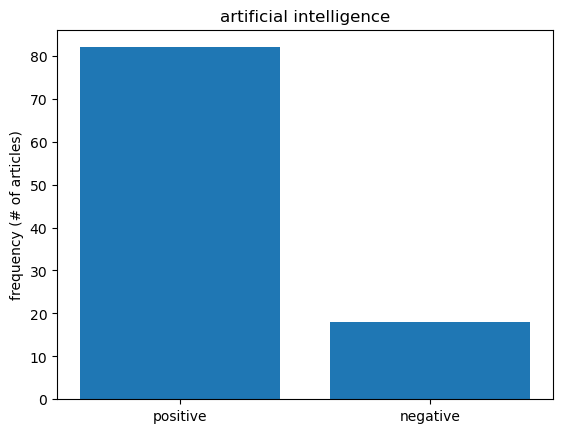

In [192]:
# Let's run a configuration to make prettier plots
plt.rcdefaults()
categories = ["positive", "negative"]
positive_count = 0
negative_count = 0
for label in sentiment_labels:
    if label == 1:
        positive_count += 1
    if label ==-1:
        negative_count += 1
counts = [positive_count, negative_count]
plt.bar(categories, counts)
plt.title(my_search_term)
plt.ylabel("frequency (# of articles)")
plt.show()

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Problem 3.2

**Write up!** Let's compare these results with our hypothesis **(Q1)**.
* Restate your hypothesis.
    *  Write: **(Q1)** _your hypothesis goes here_
* Discuss your findings.
    * How accurate was your hypothesis?
    * What do you think could have caused your guess being very accurate or inaccurate? 

We will see another way of looking at this data to find more explanations in the next part.

**(Q1)** The majority of the articles about artificial intelligence will be negative, as many focus on concerns over AI taking people's jobs and replacing humans in general. Therefore, the articles are more likely to include words associated with negative emotions. I expect about 70% of the articles to be negative.

- My initial hypothesis was wrong. There were more positive news articles in the dataset than negative for the search term of artificial intelligence. Most of the articles might focus on AI innovation and how it can be used to tackle challenges in different fields such as healthcare and education. 

<!-- END QUESTION -->

### Another Visualization: Wordclouds

For a slightly more colorful view at the overall data, we can use a wordcloud module!

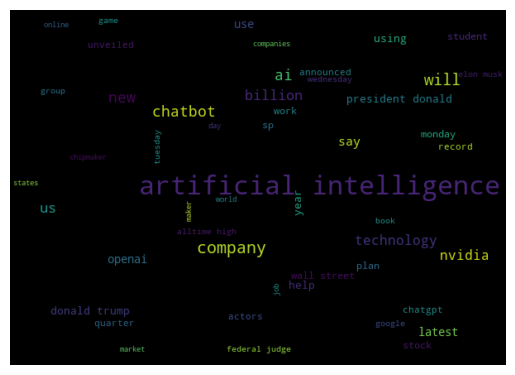

In [193]:
def get_all_words(data2plot):
    
    overallWords = ' '

    for entry in data2plot:
        for word in entry:
            overallWords += word + ' '

    return overallWords

wordcloud = WordCloud(width=600, height=430, max_words=50).generate(get_all_words(data))

plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

Now, let's look at wordclouds based on the sentiment! To do this, we split up the data into one list of lists of all positive news articles and one for all negative news articles.

In [194]:
positive_data = [i for indx,i in enumerate(data) if sentiments[indx] == 1]

negative_data = [i for indx,i in enumerate(data) if sentiments[indx] == -1]

<!-- BEGIN QUESTION -->

### Problem 3.3

**Do this!** Create one wordcloud for the postive articles and one for the negative articles, that _intuitivley_ visualizes your results. 
* Use a different `colormap` for each wordcloud (check out the availbale colormaps [here](https://matplotlib.org/stable/tutorials/colors/colormaps.html)) **and/or** 
* play with the `background_color` (check out the available colors [here](https://matplotlib.org/stable/gallery/color/named_colors.html)).
* Add appropriate titles to your subplots. 

> **Hint**: Follow the example above and use `get_all_words()`.

> **[🐍 Python Feature 🐍]**: We can create figures with **multiple plots** using `plt.subplot`. The first number indicates the number of rows, the second input is the number of columns and the third is the plot you want to fill next. Like if you want to plot into the lower right corner of a figure with four plots in a 2x2 grid, then you would use `plt.subplot(224)` 

*Note: this question is graded on style/design choices of your visualization and not just on correctness alone.*

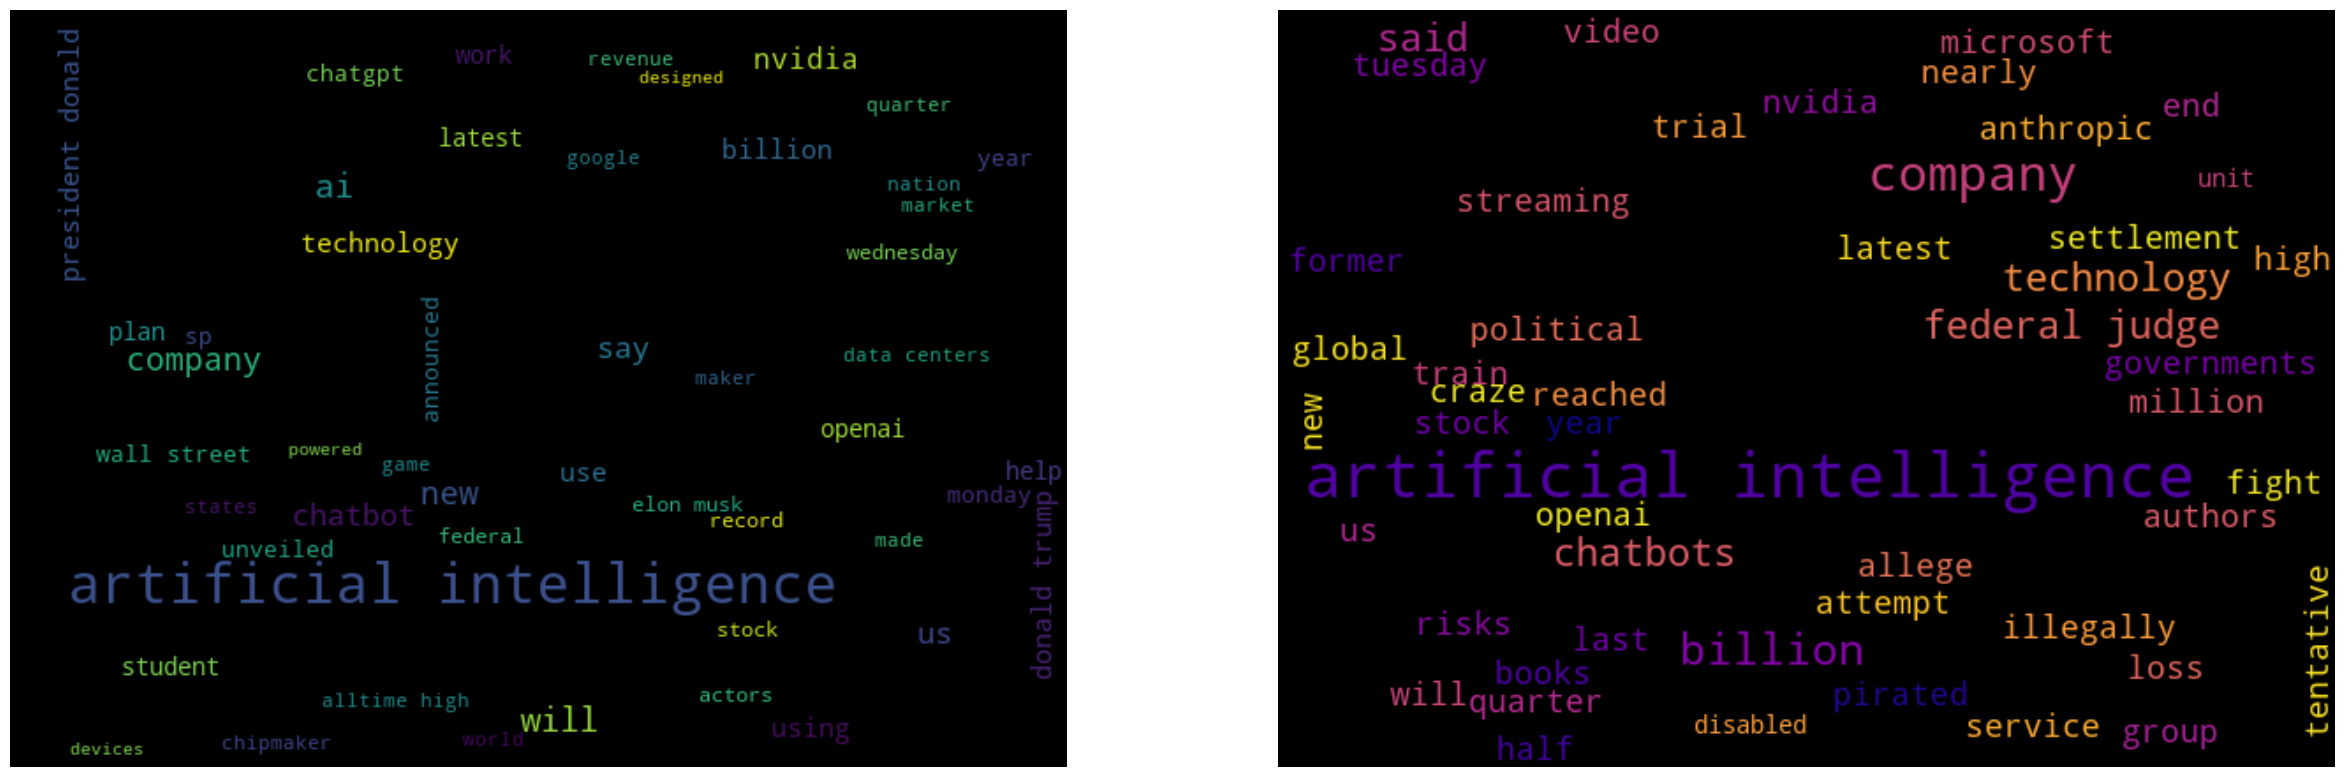

In [195]:
plt.figure(figsize=(30,15))
plt.subplot(121)

wordcloud = WordCloud(width=600, height=430, max_words=50, colormap="viridis").generate(get_all_words(positive_data))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")

plt.subplot(122)

wordcloud = WordCloud(width=600, height=430, max_words=50, colormap="plasma").generate(get_all_words(negative_data))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")

plt.show()

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Problem 3.4

**Do this!** Create a line plot visualizing the sentiment on your chose topic over time. 
* First, sort the data in increasing order based on the dates the articles were published. These dates are stored in [Unix time](https://en.wikipedia.org/wiki/Unix_time). 
> **Hint**: Recall `hw0`, where we used a lambda function to retrieve values from a dictionary.
* Next, group the sorted data into `k` bins. Choose `k` to be an appropriate value, so that 100 divides nicely by `k`. The first bin should contain the earliest `100/k` articles, while the `kth` bin should contain the most recent `100/k` articles. 
* Finally, for each bin, compute the fraction of positive news articles using the respective sentiment labels, as well as average date of publishing. Then, `fracs_pos` should contain the fraction of positive news articles for each bin, and `average_dates` should contain the average date of publishing for each bin.
> **Hint**: Because our dates are encoded in Unix time, we can compute the average date of publishing for a bin by averaging together the publishing dates for each article in the bin! 


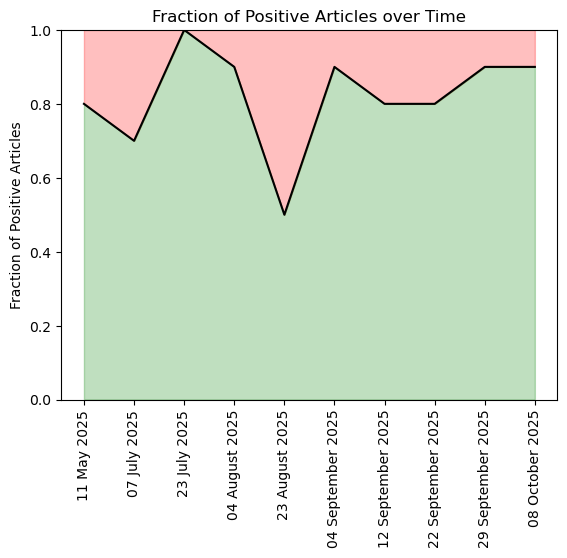

In [196]:
full_data = list(zip(data, sentiment_labels, dates))
k = 10
fracs_pos = []
average_dates = []



full_data.sort(key=lambda x:x[2])


bin_size = len(full_data) // k
start = 0

for i in range(k):
    end = start+bin_size 
    bin_data = full_data[start:end]
    count_pos = 0
    total_date = 0

    # note that a neutral sentiment score would be treated as positive
    for _, sentiment, date in bin_data:
        if sentiment >=1:
            count_pos+=1
        total_date += int(date)
    frac_pos = count_pos / len(bin_data)
    avg_date = total_date / len(bin_data)
    fracs_pos.append(frac_pos)
    average_dates.append(avg_date)
    start = end


plt.plot(range(k), fracs_pos, c='black')
plt.xticks(range(k), [datetime.datetime.fromtimestamp(d/1000).strftime("%d %B %Y") for d in average_dates], rotation = 90)
plt.ylabel('Fraction of Positive Articles')
plt.title('Fraction of Positive Articles over Time')
plt.ylim(0, 1)
plt.fill_between(range(k), 1, fracs_pos, where=fracs_pos, color='red', alpha=0.25)
plt.fill_between(range(k), 0, fracs_pos, where=fracs_pos, color='green', alpha=0.25)

plt.show()  

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

## 4. Summarize your Findings

### Problem 4.1

**Write up!** The visualizations reveal a lot of information about your news data. Describe your basic findings by answering the following questions:

* Restate your search term. (_...I know it's annoying, but this will help us grade more efficiently_)
    * Write: **Search term:** _your search term goes here_  
* Restate your hypothesis.
    *  Write: **(Q1)** _your hypothesis goes here_
* Summarize your findings.    
    - What was the overall sentiment? 
    - What were some of the most/least frequent words that were used for either sentiment (larger = more common)? Why do you think this is? 
    - How do the words used and their frequency differ for positive versus negative articles?

**Search term:** artificial intelligence

**(Q1)** The majority of the articles about artificial intelligence will be negative, as many focus on concerns over AI taking people's jobs and replacing humans in general. Therefore, the articles are more likely to include words associated with negative emotions. I expect about 70% of the articles to be negative.

**Summary:**
- The overall sentiment was positive (1).
- Some of the more common words include: artificial intelligence, us, openai, help, technology, risks, federal, chatbot.
- Some of the less common words include: stock, app, chipmaker.
- For the positive articles there are only a few words appearing more frequently (a few words dominate the analysis). In contrast, the negative articles show more variety of negative words used to calculate the score. 

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Problem 4.2

**Write up!** How does the sentiment on your chosen term change over time? Carefully describe the general trend or point out certain times with sentiment spikes. Come up with an explanation why this trend or spike(s) exists. **Cite the source(s)** of your explanation.

> **Hint:** We are analyzing news articles, dig into the article(s) or research what happened during the time period(s). 

For the period from May 22, 2025 to October 10, 2025, the sentiment of the term "artificial intelligence" remained mostly positive. There was a noticable drop beginning in late July and reaching its lowest in late August, where the fraction of positive articles fell to around 0.50. 

During August, several negative articles were published, such as "Book authors settle copyright lawsuit with AI company Anthropic" (August 26, 2025). On August 6, 2025, there are three separate publications regarding ChatGPT's potential risks to teenagers. These three articles on the same topic and the same day might contribute to an increase in negative sentiment and thus a lower fraction of positive articles observed in August.

However, it is important to consider others factors before coming to a conclusion. Despite the August drop, the majority of articles about artificial intelligence during this period highlighted the benefits of AI for different communities.

Sources:
"Book authors settle copyright lawsuit with AI company Anthropic" (https://apnews.com/article/anthropic-ai-copyright-book-authors-aa3df1aafcc95a91c09b2c22bfd49058)
"New study sheds light on ChatGPT’s alarming interactions with teens" (https://apnews.com/video/new-study-sheds-light-on-chatgpts-alarming-interactions-with-teens-96d05fae560e49b3b58c76a3b13d8f04)
"Study says ChatGPT gives teens dangerous advice on drugs and alcohol" (https://apnews.com/video/study-says-chatgpt-gives-teens-dangerous-advice-on-drugs-and-alcohol-23add30d14ab4c2a8b34311a65fc7c97)
"New study sheds light on ChatGPT’s alarming interactions with teens" / article (https://apnews.com/article/chatgpt-study-harmful-advice-teens-c569cddf28f1f33b36c692428c2191d4)

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Problem 4.3

**Write up!** Describe one specific finding or insight from your analysis that you personally deem particularly interesing (2-3 sentences). Briefly explain why you deem it insteresing and elaborate on your personal connection. 

I found the fraction of positive articles about artificial intelligence really interesting since it is the opposite to what I had expected. I would like to perform a deeper, more robust analysis since hard-coded rules might not accurately represent the general opinion about AI (neutral scores were counted as positive and we cannot interpret context). It would also be interesting to look at earlier dates and compare those scores to those for more recent dates.

<!-- END QUESTION -->

**That's it! Follow the submission instructions below:**
* Restart your kernel and run all the cells
* Save your notebook
* Upload the .ipynb notebook directly to Gradescope